# dBERT Training Curves: MLM vs DLM

In [1]:
import json
import glob
import matplotlib.pyplot as plt

def load_log(pattern):
    logs = glob.glob(pattern)
    if not logs:
        raise FileNotFoundError(f"No log found matching {pattern}")
    return [json.loads(line) for line in open(logs[0])]

def extract(entries, prefix):
    loss_key, acc_key = f"{prefix}_loss", f"{prefix}_acc"
    steps, losses, accs = [], [], []
    for e in entries:
        if loss_key in e:
            steps.append(e["step"])
            losses.append(float(e[loss_key]))
            accs.append(float(e[acc_key]))
    return steps, losses, accs

mlm_steps, mlm_loss, mlm_acc = extract(load_log("../_saved_models/mlm_*/training_log.jsonl"), "mlm")
dlm_steps, dlm_loss, dlm_acc = extract(load_log("../_saved_models/dlm_*/training_log.jsonl"), "dlm")

print(f"MLM: {len(mlm_steps)} entries, steps {mlm_steps[0]}-{mlm_steps[-1]}")
print(f"DLM: {len(dlm_steps)} entries, steps {dlm_steps[0]}-{dlm_steps[-1]}")

MLM: 20001 entries, steps 1-100000
DLM: 20001 entries, steps 1-100000


## Training Loss

Note: MLM loss is computed on 15% of tokens; DLM loss is computed on a variable fraction (~50% on average). The losses are not directly comparable in magnitude, but convergence trends are.

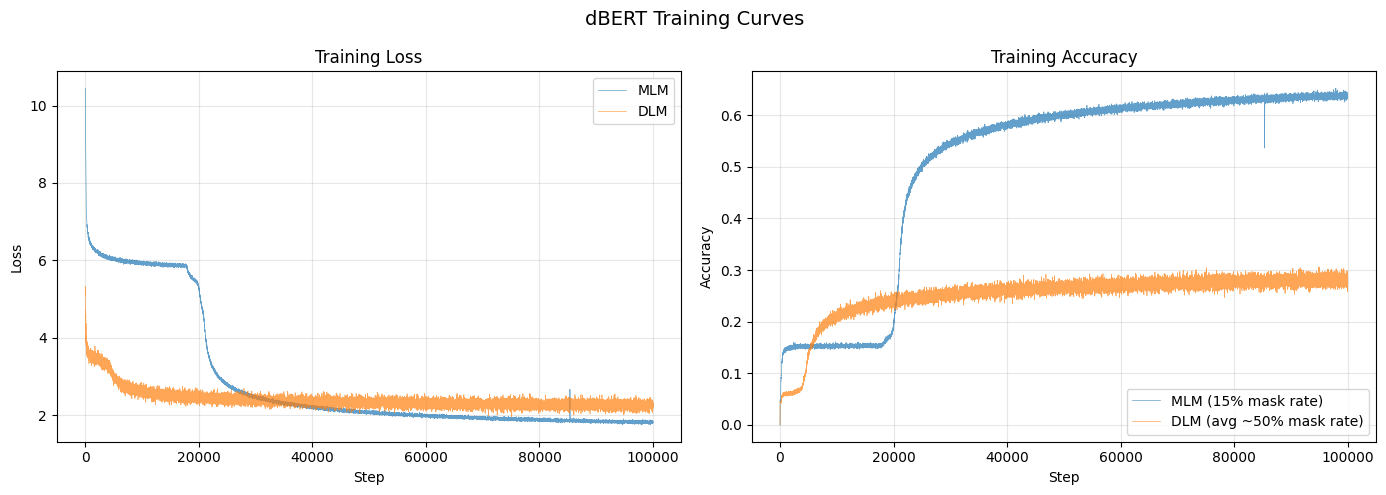

In [2]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(mlm_steps, mlm_loss, label="MLM", alpha=0.7, linewidth=0.5)
ax1.plot(dlm_steps, dlm_loss, label="DLM", alpha=0.7, linewidth=0.5)
ax1.set_xlabel("Step")
ax1.set_ylabel("Loss")
ax1.set_title("Training Loss")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(mlm_steps, mlm_acc, label="MLM (15% mask rate)", alpha=0.7, linewidth=0.5)
ax2.plot(dlm_steps, dlm_acc, label="DLM (avg ~50% mask rate)", alpha=0.7, linewidth=0.5)
ax2.set_xlabel("Step")
ax2.set_ylabel("Accuracy")
ax2.set_title("Training Accuracy")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle("dBERT Training Curves", fontsize=14)
plt.tight_layout()
plt.show()

## Smoothed Curves

Exponential moving average for clearer trends.

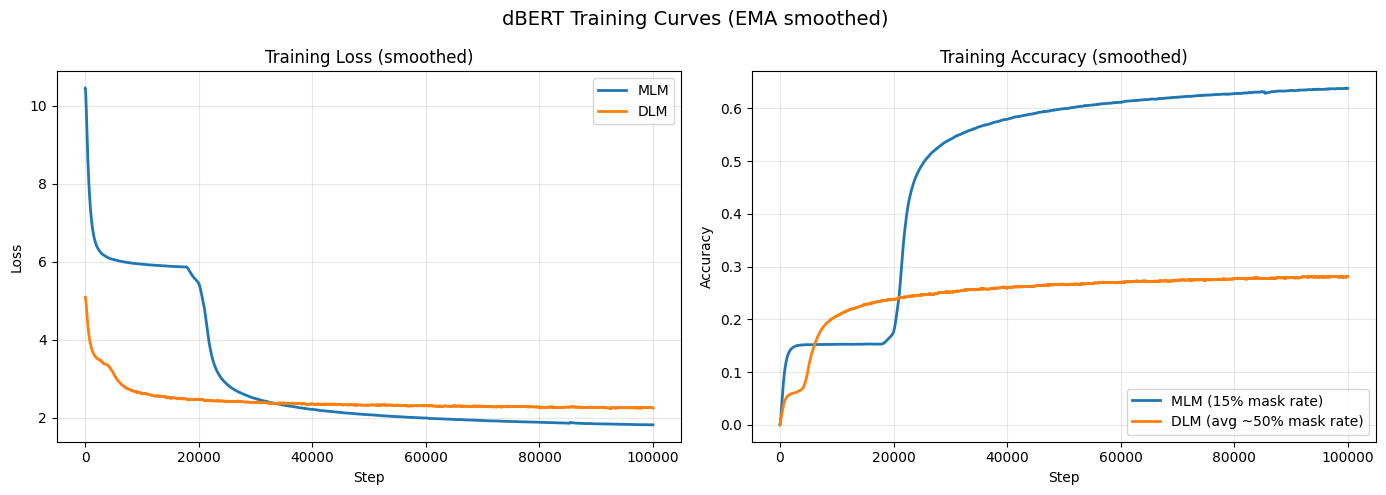

In [3]:
import numpy as np

def ema(values, alpha=0.01):
    result = []
    s = values[0]
    for v in values:
        s = alpha * v + (1 - alpha) * s
        result.append(s)
    return result

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(mlm_steps, ema(mlm_loss), label="MLM", linewidth=2)
ax1.plot(dlm_steps, ema(dlm_loss), label="DLM", linewidth=2)
ax1.set_xlabel("Step")
ax1.set_ylabel("Loss")
ax1.set_title("Training Loss (smoothed)")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(mlm_steps, ema(mlm_acc), label="MLM (15% mask rate)", linewidth=2)
ax2.plot(dlm_steps, ema(dlm_acc), label="DLM (avg ~50% mask rate)", linewidth=2)
ax2.set_xlabel("Step")
ax2.set_ylabel("Accuracy")
ax2.set_title("Training Accuracy (smoothed)")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle("dBERT Training Curves (EMA smoothed)", fontsize=14)
plt.tight_layout()
plt.show()

## Eval Results: Accuracy, Perplexity, MAUVE vs Mask Rate

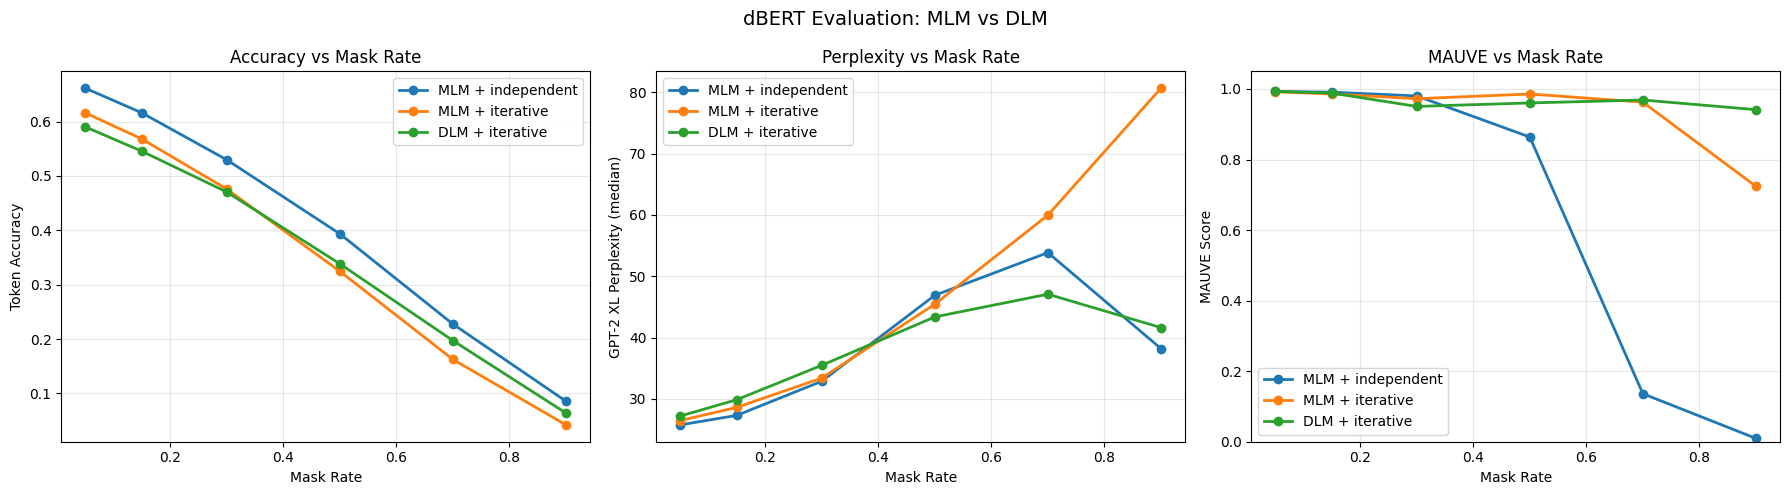

In [4]:
score_files = {
    "MLM + independent": "../_outputs/AntonXue_BERT-MLM_independent_scores.json",
    "MLM + iterative": "../_outputs/AntonXue_BERT-MLM_iterative_scores.json",
    "DLM + iterative": "../_outputs/AntonXue_BERT-DLM_iterative_scores.json",
}

scores = {}
for name, path in score_files.items():
    try:
        with open(path) as f:
            scores[name] = json.load(f)
    except FileNotFoundError:
        print(f"Warning: {path} not found, skipping")

mask_rates = [0.05, 0.15, 0.30, 0.50, 0.70, 0.90]

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

for name, data in scores.items():
    mr = data["mask_rates"]
    rates = [r for r in mask_rates if str(r) in mr]
    accs = [mr[str(r)]["accuracy"] for r in rates]
    ppls = [mr[str(r)]["median_ppl"] for r in rates]
    mauves = [mr[str(r)]["mauve"] for r in rates]

    ax1.plot(rates, accs, "o-", label=name, linewidth=2, markersize=6)
    ax2.plot(rates, ppls, "o-", label=name, linewidth=2, markersize=6)
    ax3.plot(rates, mauves, "o-", label=name, linewidth=2, markersize=6)

ax1.set_xlabel("Mask Rate")
ax1.set_ylabel("Token Accuracy")
ax1.set_title("Accuracy vs Mask Rate")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.set_xlabel("Mask Rate")
ax2.set_ylabel("GPT-2 XL Perplexity (median)")
ax2.set_title("Perplexity vs Mask Rate")
ax2.legend()
ax2.grid(True, alpha=0.3)

ax3.set_xlabel("Mask Rate")
ax3.set_ylabel("MAUVE Score")
ax3.set_title("MAUVE vs Mask Rate")
ax3.legend()
ax3.grid(True, alpha=0.3)
ax3.set_ylim(0, 1.05)

plt.suptitle("dBERT Evaluation: MLM vs DLM", fontsize=14)
plt.tight_layout()
plt.show()